# Retention Campaign — Learning Phase Analysis
## Daily Model Prediction Bias vs Cumulative Installs

This notebook evaluates the learning phase for the new **Retention campaign** product,
analyzing when the D7 retention prediction model stabilizes relative to cumulative installs.

**Key metric**: Retention model bias = `SUM(ret_d7_prob_sum) / SUM(retained_d7) - 1`
- `ret_d7_prob_sum`: sum of predicted D7 retention probabilities per install
- `retained_d7`: actual number of users retained at Day 7
- Bias of 0 = perfect prediction; positive = over-prediction; negative = under-prediction

**Analysis window**: Last 3 months


## Setup and Imports


In [20]:
# @title
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

try:
    from google.colab import auth
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

from google.cloud import bigquery

plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')
print('✅ Imports complete')
print(f'   Running in Colab: {IN_COLAB}')


✅ Imports complete
   Running in Colab: True


In [21]:
# @title — Analysis configuration (edit here to change behaviour across all steps)

# Time window
ANALYSIS_START_DATE = '2026-02-10'   # inclusive start date for all queries

# Model bias threshold
BIAS_THRESHOLD = 0.20                 # ±20%  (pred/actual - 1)

# Rolling average window
ROLLING_WINDOW = 7                    # days
MA_MIN_PERIODS = 3                    # minimum observations before MA is computed

# Stabilization rule
STREAK_DAYS        = 3                # consecutive days inside threshold to enter "stable"
POST_STABLE_MIN_DAYS = 7              # min days after stabilization point required to validate it
POST_STABLE_MIN_PCT  = 0.70           # fraction of post-entry days that must stay inside threshold

# Noise filters
MIN_DAILY_RETAINED_FILTER = 5         # drop rows with fewer retained D7 (too noisy for bias)

# Sensitivity analysis thresholds (cumulative installs)
SENSITIVITY_THRESHOLDS_INSTALLS  = [200, 500, 1_000, 2_000, 5_000]
# Sensitivity analysis thresholds (cumulative retained D7)
SENSITIVITY_THRESHOLDS_RETAINED  = [50, 100, 200, 500, 1_000]

print('✅ Constants configured')
print(f'   Analysis start date : {ANALYSIS_START_DATE}')
print(f'   Bias threshold      : ±{BIAS_THRESHOLD*100:.0f}%')
print(f'   Rolling window      : {ROLLING_WINDOW} days (min {MA_MIN_PERIODS} periods)')
print(f'   Stabilization       : {STREAK_DAYS}-day streak + {POST_STABLE_MIN_PCT*100:.0f}% of ≥{POST_STABLE_MIN_DAYS} post-entry days')


✅ Constants configured
   Analysis start date : 2026-02-10
   Bias threshold      : ±20%
   Rolling window      : 7 days (min 3 periods)
   Stabilization       : 3-day streak + 70% of ≥7 post-entry days


## BigQuery Authentication


In [22]:
# @title
if IN_COLAB:
    auth.authenticate_user()
    print('✅ Authenticated with Google Cloud')
else:
    print('ℹ️  Using default application credentials (local run)')

project_id = 'unity-data-ads-ad-hoc-prd'
client = bigquery.Client(project=project_id)
print(f'✅ BigQuery client initialized for project: {project_id}')


✅ Authenticated with Google Cloud
✅ BigQuery client initialized for project: unity-data-ads-ad-hoc-prd


## Step 1 — Find Games Running Retention Campaigns (last 3 months)

Identifies all games that have run Retention campaigns in the past 3 months using
`operative_outcomes_dcpi_join_demand`. Returns up to 500 games ordered by recency and spend.


In [8]:
game_selection_query = f'''
WITH base AS (
  SELECT
    target_game_id,
    submit_date,
    spend_sum,
    retained_d7,
    ret_d7_prob_sum
  FROM `unity-data-ads-core-prd.ads_secondary_conversion.operative_outcomes_dcpi_join_demand`
  WHERE app_events_campaign_type = 'RETENTION'
    AND submit_date >= '{ANALYSIS_START_DATE}'
    AND submit_date < CURRENT_DATE('UTC')
    AND install_hour IS NOT NULL
),
game_stats AS (
  SELECT
    target_game_id,
    MIN(DATE(submit_date)) AS first_retention_date,
    MAX(DATE(submit_date)) AS last_retention_date,
    COUNT(DISTINCT DATE(submit_date)) AS days_with_data,
    SUM(spend_sum) AS total_spend,
    SUM(retained_d7) AS total_retained_d7,
    SUM(ret_d7_prob_sum) AS total_ret_d7_prob_sum
  FROM base
  GROUP BY target_game_id
  HAVING total_retained_d7 > 10
)
SELECT
  CAST(target_game_id AS STRING) AS target_game_id,
  first_retention_date,
  last_retention_date,
  days_with_data,
  total_spend,
  total_retained_d7,
  SAFE_DIVIDE(total_ret_d7_prob_sum, total_retained_d7) - 1 AS overall_model_bias
FROM game_stats
ORDER BY total_spend DESC
LIMIT 500
'''

print(f'🔍 Finding games with Retention campaigns since {ANALYSIS_START_DATE}...')
game_list_df = client.query(game_selection_query).to_dataframe()
# Standardize game_id as string throughout
game_list_df['target_game_id'] = game_list_df['target_game_id'].astype(str)
game_ids = game_list_df['target_game_id'].tolist()

print(f'✅ Found {len(game_ids)} games with sufficient D7 retention data')
print(f'   Date range: {game_list_df["first_retention_date"].min()} to {game_list_df["last_retention_date"].max()}')
print(f'\n📊 Top 10 games by spend:')
display(game_list_df.head(10))


🔍 Finding games with Retention campaigns since 2026-02-10...
✅ Found 60 games with sufficient D7 retention data
   Date range: 2026-02-24 to 2026-05-25

📊 Top 10 games by spend:


,target_game_id,first_retention_date,last_retention_date,days_with_data,total_spend,total_retained_d7,overall_model_bias
0,500237245,2026-02-24,2026-05-25,91,418461.332055,38727,0.188738
1,500241521,2026-02-24,2026-05-25,91,124586.896375,3895,0.270551
2,500196051,2026-02-24,2026-05-25,91,91819.902596,2356,0.114561
3,11076,2026-04-01,2026-05-25,36,91485.606427,3105,0.488739
4,1566453,2026-04-28,2026-05-25,28,90499.124434,4448,0.733351
5,1434564,2026-03-12,2026-05-25,75,90487.025644,7341,0.217839
6,500219388,2026-02-24,2026-05-07,73,71478.590308,1521,-0.031043
7,132367,2026-04-23,2026-05-25,33,64156.055099,2708,0.718284
8,500017356,2026-03-12,2026-05-25,75,62941.193976,3329,0.240175
9,500199981,2026-02-24,2026-04-23,59,58516.008368,2828,-0.014199


## Step 2 — Query Daily Model Accuracy & Installs Per Game

For each game: fetches daily installs, retained D7 actuals, predicted D7 probabilities,
and spend. Then computes cumulative installs and rolling 7-day model bias.


In [9]:
game_ids_str = ', '.join([f"'{gid}'" for gid in game_ids])

main_query_template = f"""
WITH daily_data AS (
  SELECT
    CAST(target_game_id AS STRING) AS game_id,
    DATE(submit_date)              AS date,
    COUNT(*)                       AS daily_installs,
    SUM(retained_d7)               AS daily_retained_d7,
    SUM(ret_d7_prob_sum)           AS daily_ret_d7_prob_sum,
    SUM(spend_sum)                 AS daily_spend
  FROM `unity-data-ads-core-prd.ads_secondary_conversion.operative_outcomes_dcpi_join_demand`
  WHERE app_events_campaign_type = 'RETENTION'
    AND CAST(target_game_id AS STRING) IN ({{game_ids}})
    AND submit_date >= '{ANALYSIS_START_DATE}'
    AND submit_date < CURRENT_DATE('UTC')
    AND install_hour IS NOT NULL
    AND DATE_DIFF(CURRENT_DATE('UTC'), DATE(install_hour), DAY) >= 8
  GROUP BY CAST(target_game_id AS STRING), DATE(submit_date)
)
SELECT
  game_id,
  date,
  daily_installs,
  daily_retained_d7,
  daily_ret_d7_prob_sum,
  daily_spend,
  SAFE_DIVIDE(daily_ret_d7_prob_sum, daily_retained_d7) - 1 AS daily_model_bias
FROM daily_data
WHERE daily_retained_d7 > 0
ORDER BY game_id, date
"""
main_query = main_query_template.format(game_ids=game_ids_str)

print(f'🔍 Querying daily data for {len(game_ids)} games since {ANALYSIS_START_DATE}...')
print(f'📅 D7 window filter: install >= 8 days ago')
df = client.query(main_query).to_dataframe()
df['date']    = pd.to_datetime(df['date'])
df['game_id'] = df['game_id'].astype(str)

print(f'✅ Data loaded: {len(df):,} rows')
print(f'🎮 Games found: {df["game_id"].nunique()} games')
print(f'📅 Date range: {df["date"].min().date()} to {df["date"].max().date()}')
print('\n📊 Data Preview:')
display(df.head(10))


🔍 Querying daily data for 60 games since 2026-02-10...
📅 D7 window filter: install >= 8 days ago
✅ Data loaded: 1,727 rows
🎮 Games found: 60 games
📅 Date range: 2026-02-24 to 2026-05-18

📊 Data Preview:


,game_id,date,daily_installs,daily_retained_d7,daily_ret_d7_prob_sum,daily_spend,daily_model_bias
0,11075,2026-04-02,5,1,1.032154,5.160771,0.032154
1,11075,2026-04-03,9,2,1.886840,12.364363,-0.056580
2,11075,2026-04-04,19,3,3.826961,26.788726,0.275654
3,11075,2026-04-05,13,3,3.246477,22.725340,0.082159
4,11075,2026-04-06,16,6,4.011212,28.078484,-0.331465
5,11075,2026-04-07,17,4,4.032683,28.228785,0.008171
6,11075,2026-04-08,28,10,5.805410,56.046645,-0.419459
7,11075,2026-04-09,119,14,24.473223,361.774717,0.748087
8,11075,2026-04-10,216,37,41.799074,631.971881,0.129705
9,11075,2026-04-11,184,40,35.998932,539.983993,-0.100027


## Step 3 — Feature Engineering

Compute per-game: cumulative installs, cumulative retained D7, 7-day rolling model bias,
and days since campaign start.


In [10]:
# Sort for windowed operations
df = df.sort_values(['game_id', 'date']).reset_index(drop=True)

# Cumulative installs and retained D7 per game
df['cumulative_installs']    = df.groupby('game_id')['daily_installs'].cumsum()
df['cumulative_retained_d7'] = df.groupby('game_id')['daily_retained_d7'].cumsum()

# Days since campaign start per game
df['campaign_start']   = df.groupby('game_id')['date'].transform('min')
df['days_since_start'] = (df['date'] - df['campaign_start']).dt.days

# Rolling weighted model bias (min_periods from constant)
def rolling_weighted_bias(group):
    group = group.sort_values('date')
    prob_roll   = group['daily_ret_d7_prob_sum'].rolling(window=ROLLING_WINDOW, min_periods=MA_MIN_PERIODS).sum()
    actual_roll = group['daily_retained_d7'].rolling(window=ROLLING_WINDOW, min_periods=MA_MIN_PERIODS).sum()
    group['model_bias_ma7'] = prob_roll / actual_roll.replace(0, np.nan) - 1
    return group

df = df.groupby('game_id', group_keys=False).apply(rolling_weighted_bias)
df['abs_model_bias_ma7'] = df['model_bias_ma7'].abs()

print(f'✅ Feature engineering complete')
print(f'   Cumulative installs range: {df["cumulative_installs"].min():,.0f} – {df["cumulative_installs"].max():,.0f}')
print(f'   Cumulative retained D7 range: {df["cumulative_retained_d7"].min():,.0f} – {df["cumulative_retained_d7"].max():,.0f}')
print(f'   Model bias range: {df["daily_model_bias"].min():.4f} – {df["daily_model_bias"].max():.4f}')
print(f'   Rolling bias (MA{ROLLING_WINDOW}) range: {df["model_bias_ma7"].dropna().min():.4f} – {df["model_bias_ma7"].dropna().max():.4f}')
display(df[['game_id','date','cumulative_installs','cumulative_retained_d7','days_since_start','daily_model_bias','model_bias_ma7']].head(15))


✅ Feature engineering complete
   Cumulative installs range: 1 – 181,929
   Cumulative retained D7 range: 1 – 38,727
   Model bias range: -0.9375 – 4.4524
   Rolling bias (MA7) range: -0.5787 – 1.2368


,game_id,date,cumulative_installs,cumulative_retained_d7,days_since_start,daily_model_bias,model_bias_ma7
0,11075,2026-04-02,5,1,0,0.032154,NaN
1,11075,2026-04-03,14,3,1,-0.056580,NaN
2,11075,2026-04-04,33,6,2,0.275654,0.124326
3,11075,2026-04-05,46,9,3,0.082159,0.110270
4,11075,2026-04-06,62,15,4,-0.331465,-0.066424
5,11075,2026-04-07,79,19,5,0.008171,-0.050720
6,11075,2026-04-08,107,29,6,-0.419459,-0.177871
7,11075,2026-04-09,226,43,7,0.748087,0.125781
8,11075,2026-04-10,442,80,8,0.129705,0.132403
9,11075,2026-04-11,626,120,9,-0.100027,0.047079


## Step 4 — Aggregate View: Population-Level Model Accuracy Over Time

Plots the population-level daily model bias (aggregated across all games) and cumulative installs
to show the overall learning trajectory.


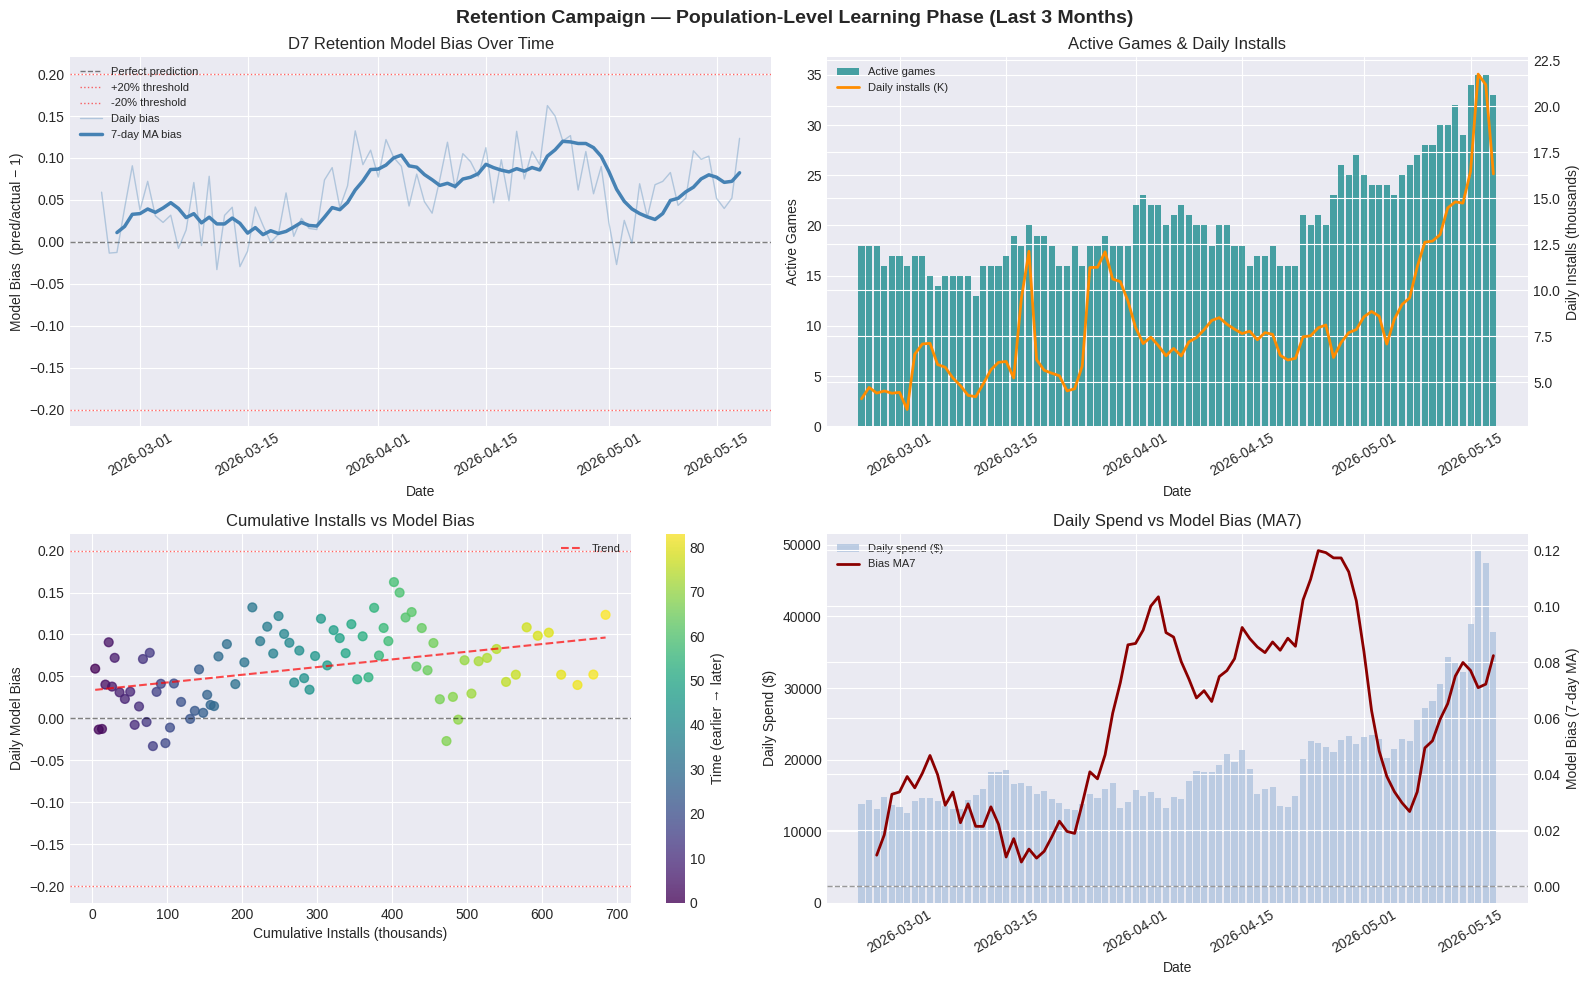


📊 Population-Level Summary:
   Mean daily model bias: 0.0599
   Std daily model bias:  0.0440
   Pct days within ±20%:  100.0%
   Correlation (cum_installs vs bias): 0.3954


In [11]:
# Population-level aggregation by date
df_agg = df.groupby('date').agg(
    total_daily_installs=('daily_installs', 'sum'),
    total_retained_d7=('daily_retained_d7', 'sum'),
    total_ret_d7_prob_sum=('daily_ret_d7_prob_sum', 'sum'),
    total_spend=('daily_spend', 'sum'),
    active_games=('game_id', 'nunique')
).reset_index().sort_values('date')

df_agg['model_bias'] = df_agg['total_ret_d7_prob_sum'] / df_agg['total_retained_d7'].replace(0, np.nan) - 1
df_agg['model_bias_ma7'] = df_agg['model_bias'].rolling(window=7, min_periods=3).mean()
df_agg['cumulative_installs'] = df_agg['total_daily_installs'].cumsum()

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle('Retention Campaign — Population-Level Learning Phase (Last 3 Months)', fontsize=14, fontweight='bold')

# Plot 1: Model bias over calendar time
ax1 = axes[0, 0]
ax1.axhline(0, color='black', linewidth=1, linestyle='--', alpha=0.5, label='Perfect prediction')
ax1.axhline(0.2, color='red', linewidth=1, linestyle=':', alpha=0.6, label='+20% threshold')
ax1.axhline(-0.2, color='red', linewidth=1, linestyle=':', alpha=0.6, label='-20% threshold')
ax1.plot(df_agg['date'], df_agg['model_bias'], alpha=0.35, color='steelblue', linewidth=1, label='Daily bias')
ax1.plot(df_agg['date'], df_agg['model_bias_ma7'], color='steelblue', linewidth=2.5, label='7-day MA bias')
ax1.set_title('D7 Retention Model Bias Over Time')
ax1.set_xlabel('Date')
ax1.set_ylabel('Model Bias  (pred/actual − 1)')
ax1.legend(fontsize=8)
ax1.tick_params(axis='x', rotation=30)

# Plot 2: Active games over time
ax2 = axes[0, 1]
ax2.bar(df_agg['date'], df_agg['active_games'], color='teal', alpha=0.7, label='Active games')
ax2_twin = ax2.twinx()
ax2_twin.plot(df_agg['date'], df_agg['total_daily_installs'] / 1000, color='darkorange', linewidth=2, label='Daily installs (K)')
ax2.set_title('Active Games & Daily Installs')
ax2.set_xlabel('Date')
ax2.set_ylabel('Active Games')
ax2_twin.set_ylabel('Daily Installs (thousands)')
ax2.tick_params(axis='x', rotation=30)
lines1, labels1 = ax2.get_legend_handles_labels()
lines2, labels2 = ax2_twin.get_legend_handles_labels()
ax2.legend(lines1 + lines2, labels1 + labels2, fontsize=8)

# Plot 3: Cumulative installs vs model bias (scatter)
ax3 = axes[1, 0]
sc = ax3.scatter(df_agg['cumulative_installs'] / 1000, df_agg['model_bias'],
                 c=range(len(df_agg)), cmap='viridis', s=40, alpha=0.75)
ax3.axhline(0, color='black', linewidth=1, linestyle='--', alpha=0.5)
ax3.axhline(0.2, color='red', linewidth=1, linestyle=':', alpha=0.6)
ax3.axhline(-0.2, color='red', linewidth=1, linestyle=':', alpha=0.6)
z = np.polyfit(df_agg['cumulative_installs'].dropna(), df_agg['model_bias'].dropna(), 1)
p = np.poly1d(z)
ax3.plot(df_agg['cumulative_installs'] / 1000, p(df_agg['cumulative_installs']), 'r--', linewidth=1.5, alpha=0.7, label='Trend')
plt.colorbar(sc, ax=ax3, label='Time (earlier → later)')
ax3.set_title('Cumulative Installs vs Model Bias')
ax3.set_xlabel('Cumulative Installs (thousands)')
ax3.set_ylabel('Daily Model Bias')
ax3.legend(fontsize=8)

# Plot 4: Spend over time + bias overlay
ax4 = axes[1, 1]
ax4.bar(df_agg['date'], df_agg['total_spend'], color='lightsteelblue', alpha=0.8, label='Daily spend ($)')
ax4_twin = ax4.twinx()
ax4_twin.plot(df_agg['date'], df_agg['model_bias_ma7'], color='darkred', linewidth=2, label='Bias MA7')
ax4_twin.axhline(0, color='black', linewidth=1, linestyle='--', alpha=0.4)
ax4.set_title('Daily Spend vs Model Bias (MA7)')
ax4.set_xlabel('Date')
ax4.set_ylabel('Daily Spend ($)')
ax4_twin.set_ylabel('Model Bias (7-day MA)')
ax4.tick_params(axis='x', rotation=30)
lines1, labels1 = ax4.get_legend_handles_labels()
lines2, labels2 = ax4_twin.get_legend_handles_labels()
ax4.legend(lines1 + lines2, labels1 + labels2, fontsize=8)

plt.tight_layout()
plt.show()

print('\n📊 Population-Level Summary:')
print(f'   Mean daily model bias: {df_agg["model_bias"].mean():.4f}')
print(f'   Std daily model bias:  {df_agg["model_bias"].std():.4f}')
print(f'   Pct days within ±20%:  {(df_agg["model_bias"].abs() < 0.2).mean()*100:.1f}%')
print(f'   Correlation (cum_installs vs bias): {np.corrcoef(df_agg["cumulative_installs"].dropna(), df_agg["model_bias"].dropna())[0,1]:.4f}')


### Step 4b — Outlier Diagnostic: Top 5 Games vs Rest of Population

Confirms whether the upward drift in mean bias is driven by a few high-spend outlier games
or is a universal model degradation. Plots individual MA7 bias trajectories for the top 5 games
by total spend, overlaid against the median of all remaining games.

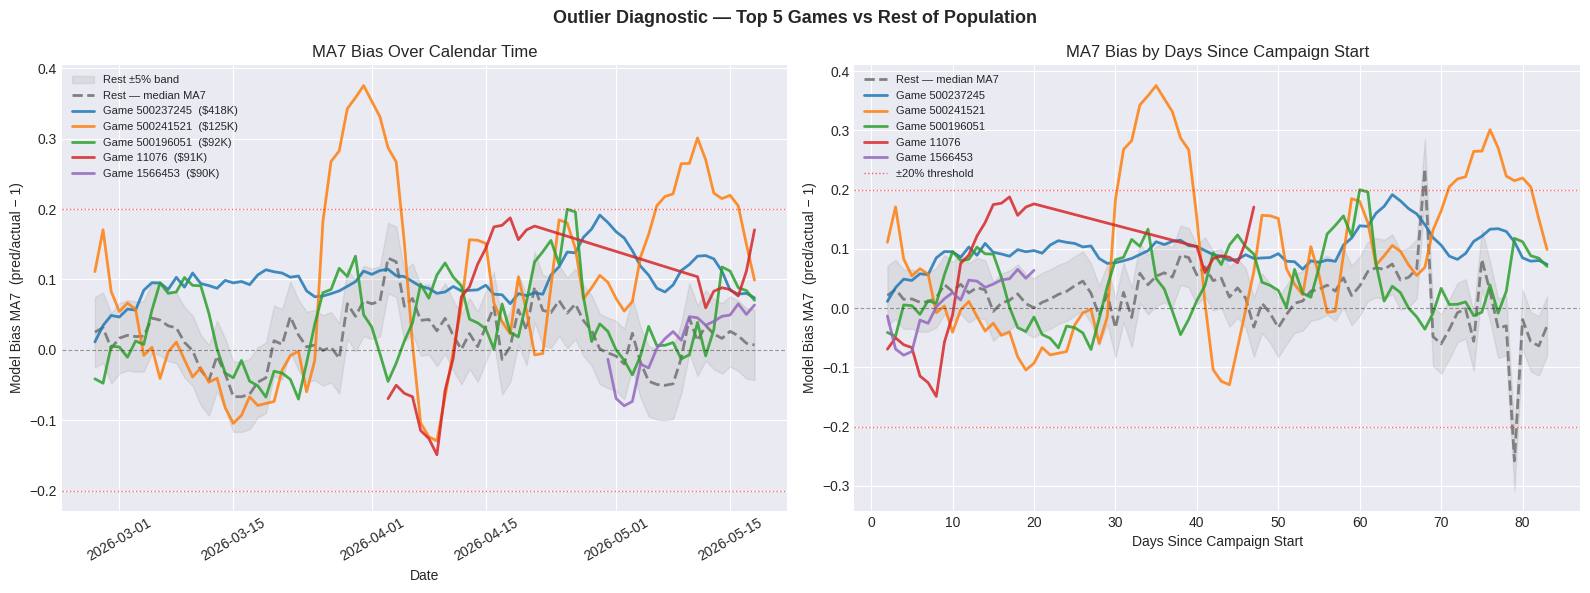

📊 Top 5 vs Rest — bias summary:

  Top 5 (5 games):
    Mean MA7 bias  : 0.0707
    Median MA7 bias: 0.0800
    % within ±20%  : 93.2%

  Rest (55 games):
    Mean MA7 bias  : 0.0415
    Median MA7 bias: 0.0239
    % within ±20%  : 81.7%


In [23]:
TOP_N = 5

# Top N games by total spend (already ordered in game_list_df)
top5_ids  = game_list_df.head(TOP_N)['target_game_id'].tolist()
rest_ids  = game_list_df.iloc[TOP_N:]['target_game_id'].tolist()

df_top5 = df[df['game_id'].isin(top5_ids)].copy()
df_rest = df[df['game_id'].isin(rest_ids)].copy()

# Population median MA7 for the "rest" games, by calendar date
rest_median = (
    df_rest[df_rest['model_bias_ma7'].notna()]
    .groupby('date')['model_bias_ma7']
    .median()
    .reset_index()
    .rename(columns={'model_bias_ma7': 'median_bias'})
)

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Outlier Diagnostic — Top 5 Games vs Rest of Population', fontsize=13, fontweight='bold')

colors_top5 = plt.cm.tab10.colors[:TOP_N]

# Left: bias over calendar time
ax1 = axes[0]
ax1.fill_between(rest_median['date'],
                 rest_median['median_bias'] - 0.05,
                 rest_median['median_bias'] + 0.05,
                 alpha=0.15, color='gray', label='Rest ±5% band')
ax1.plot(rest_median['date'], rest_median['median_bias'],
         color='gray', linewidth=2, linestyle='--', label='Rest — median MA7')

for gid, color in zip(top5_ids, colors_top5):
    gd = df_top5[df_top5['game_id'] == gid].sort_values('date')
    valid = gd['model_bias_ma7'].notna()
    spend = game_list_df.loc[game_list_df['target_game_id'] == gid, 'total_spend'].values[0]
    ax1.plot(gd.loc[valid, 'date'], gd.loc[valid, 'model_bias_ma7'],
             color=color, linewidth=2, alpha=0.85,
             label=f'Game {gid}  (${spend/1e3:.0f}K)')

ax1.axhline( BIAS_THRESHOLD, color='red', linewidth=1, linestyle=':', alpha=0.6)
ax1.axhline(-BIAS_THRESHOLD, color='red', linewidth=1, linestyle=':', alpha=0.6)
ax1.axhline(0, color='black', linewidth=0.8, linestyle='--', alpha=0.4)
ax1.set_title('MA7 Bias Over Calendar Time')
ax1.set_xlabel('Date')
ax1.set_ylabel('Model Bias MA7  (pred/actual − 1)')
ax1.tick_params(axis='x', rotation=30)
ax1.legend(fontsize=8, loc='upper left')

# Right: bias by days since campaign start (aligned trajectories)
ax2 = axes[1]

rest_day_median = (
    df_rest[df_rest['model_bias_ma7'].notna()]
    .groupby('days_since_start')['model_bias_ma7']
    .median()
    .reset_index()
    .rename(columns={'model_bias_ma7': 'median_bias'})
)
ax2.fill_between(rest_day_median['days_since_start'],
                 rest_day_median['median_bias'] - 0.05,
                 rest_day_median['median_bias'] + 0.05,
                 alpha=0.15, color='gray')
ax2.plot(rest_day_median['days_since_start'], rest_day_median['median_bias'],
         color='gray', linewidth=2, linestyle='--', label='Rest — median MA7')

for gid, color in zip(top5_ids, colors_top5):
    gd = df_top5[df_top5['game_id'] == gid].sort_values('days_since_start')
    valid = gd['model_bias_ma7'].notna()
    ax2.plot(gd.loc[valid, 'days_since_start'], gd.loc[valid, 'model_bias_ma7'],
             color=color, linewidth=2, alpha=0.85, label=f'Game {gid}')

ax2.axhline( BIAS_THRESHOLD, color='red', linewidth=1, linestyle=':', alpha=0.6, label=f'±{BIAS_THRESHOLD*100:.0f}% threshold')
ax2.axhline(-BIAS_THRESHOLD, color='red', linewidth=1, linestyle=':', alpha=0.6)
ax2.axhline(0, color='black', linewidth=0.8, linestyle='--', alpha=0.4)
ax2.set_title('MA7 Bias by Days Since Campaign Start')
ax2.set_xlabel('Days Since Campaign Start')
ax2.set_ylabel('Model Bias MA7  (pred/actual − 1)')
ax2.legend(fontsize=8, loc='upper left')

plt.tight_layout()
plt.show()

# ── Summary table ─────────────────────────────────────────────────────────────
print(f'📊 Top {TOP_N} vs Rest — bias summary:')
for label, gids in [('Top 5', top5_ids), ('Rest', rest_ids)]:
    sub = df[df['game_id'].isin(gids) & df['model_bias_ma7'].notna()]
    print(f'\n  {label} ({len(gids)} games):')
    print(f'    Mean MA7 bias  : {sub["model_bias_ma7"].mean():.4f}')
    print(f'    Median MA7 bias: {sub["model_bias_ma7"].median():.4f}')
    print(f'    % within ±{BIAS_THRESHOLD*100:.0f}%  : {(sub["model_bias_ma7"].abs() < BIAS_THRESHOLD).mean()*100:.1f}%')


## Step 5 — Learning Curve: Model Bias by Cumulative Installs Bucket

Bins all game-day observations by cumulative install count and computes median absolute bias
per bucket — showing when the model stabilizes as more data accumulates.


📊 Rows after outlier filter (5th–95th pct): 1,302 (from 1,448)

📊 Model Bias by Cumulative Install Bucket (threshold = ±20%):
install_bin  median    mean    std  count  pct_within_threshold
       0–50  0.0800  0.0275 0.1416      6              100.0000
     50–100  0.0802  0.0168 0.1529      6               83.3333
    100–200 -0.0357 -0.0296 0.1405     35               82.8571
    200–500  0.0472  0.0614 0.1787     84               75.0000
     500–1K  0.0135  0.0233 0.1629    108               77.7778
      1K–2K  0.0044  0.0212 0.1569    151               80.1325
      2K–5K  0.0053  0.0330 0.1577    282               82.2695
     5K–10K  0.0317  0.0516 0.1522    289               83.0450
       10K+  0.0785  0.0820 0.1487    341               79.1789


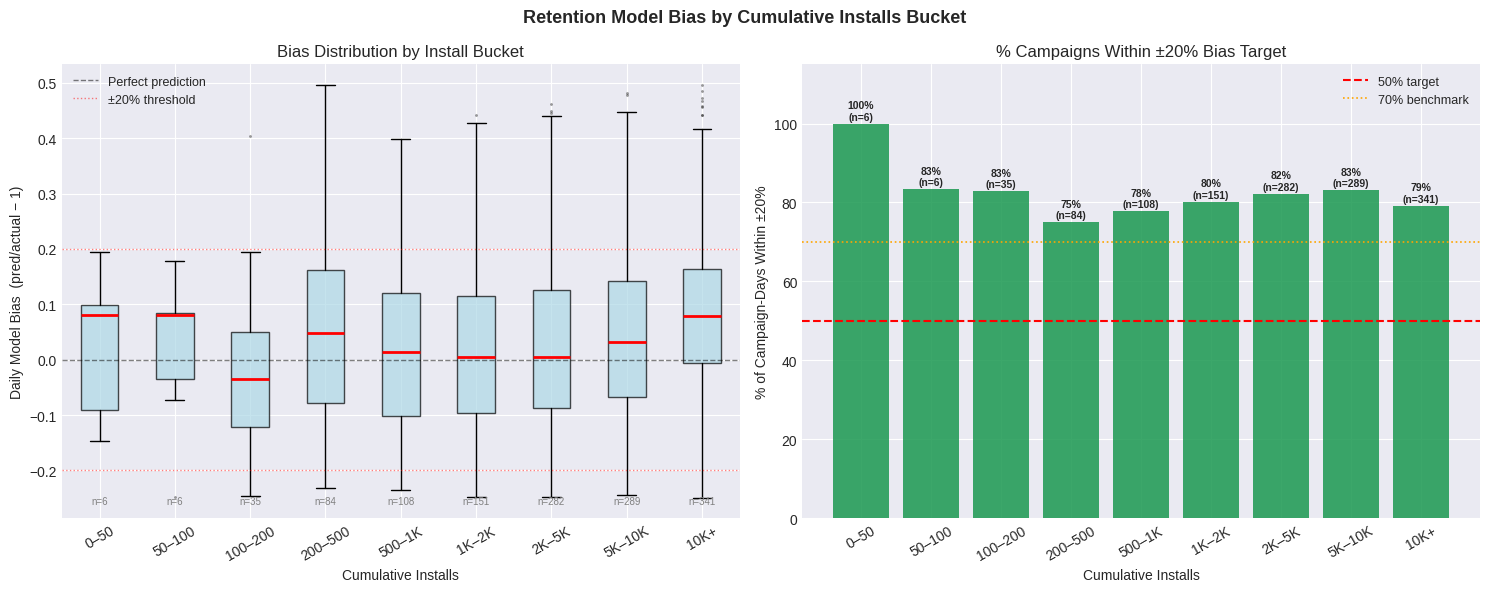

In [12]:
# Filter: require enough retained D7 for a meaningful bias estimate
df_valid = df[df['daily_retained_d7'] > MIN_DAILY_RETAINED_FILTER].copy()

# Clamp extreme outliers for display (keep 5th–95th percentile)
p5  = df_valid['daily_model_bias'].quantile(0.05)
p95 = df_valid['daily_model_bias'].quantile(0.95)
df_filtered = df_valid[
    (df_valid['daily_model_bias'] >= p5) &
    (df_valid['daily_model_bias'] <= p95)
].copy()
print(f'📊 Rows after outlier filter (5th–95th pct): {len(df_filtered):,} (from {len(df_valid):,})')

# Define install buckets
install_bins   = [0, 50, 100, 200, 500, 1000, 2000, 5000, 10000, np.inf]
install_labels = ['0–50', '50–100', '100–200', '200–500', '500–1K', '1K–2K', '2K–5K', '5K–10K', '10K+']

df_filtered['install_bin'] = pd.cut(
    df_filtered['cumulative_installs'],
    bins=install_bins, labels=install_labels, right=False
)

bin_summary = df_filtered.groupby('install_bin', observed=True)['daily_model_bias'].agg(
    median='median',
    mean='mean',
    std='std',
    count='count',
    pct_within_threshold=lambda x: (x.abs() < BIAS_THRESHOLD).mean() * 100
).reset_index()

print(f'\n📊 Model Bias by Cumulative Install Bucket (threshold = ±{BIAS_THRESHOLD*100:.0f}%):')
print(bin_summary.to_string(index=False, float_format='{:.4f}'.format))

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
fig.suptitle('Retention Model Bias by Cumulative Installs Bucket', fontsize=13, fontweight='bold')

# Boxplot per bucket
ax1 = axes[0]
plot_data    = [df_filtered[df_filtered['install_bin'] == b]['daily_model_bias'].dropna().values for b in install_labels if b in df_filtered['install_bin'].cat.categories]
valid_labels = [b for b in install_labels if b in df_filtered['install_bin'].cat.categories and len(df_filtered[df_filtered['install_bin'] == b]) > 0]
bps = ax1.boxplot(plot_data, labels=valid_labels, patch_artist=True,
                  medianprops=dict(color='red', linewidth=2),
                  flierprops=dict(marker='.', markersize=2, alpha=0.4))
for patch in bps['boxes']:
    patch.set_facecolor('lightblue')
    patch.set_alpha(0.7)
ax1.axhline(0,               color='black', linewidth=1,   linestyle='--', alpha=0.5, label='Perfect prediction')
ax1.axhline( BIAS_THRESHOLD, color='red',   linewidth=1,   linestyle=':',  alpha=0.5, label=f'±{BIAS_THRESHOLD*100:.0f}% threshold')
ax1.axhline(-BIAS_THRESHOLD, color='red',   linewidth=1,   linestyle=':',  alpha=0.5)
# Annotate n per bucket
for i, lbl in enumerate(valid_labels):
    n = int(bin_summary.loc[bin_summary['install_bin'] == lbl, 'count'].values[0])
    ax1.text(i + 1, ax1.get_ylim()[0] * 0.92, f'n={n}', ha='center', va='bottom', fontsize=7, color='gray')
ax1.set_title('Bias Distribution by Install Bucket')
ax1.set_xlabel('Cumulative Installs')
ax1.set_ylabel('Daily Model Bias  (pred/actual − 1)')
ax1.tick_params(axis='x', rotation=30)
ax1.legend(fontsize=9)

# % within threshold per bucket
ax2 = axes[1]
colors = ['#d73027' if v < 50 else '#fee090' if v < 70 else '#1a9850' for v in bin_summary['pct_within_threshold']]
bars = ax2.bar(bin_summary['install_bin'].astype(str), bin_summary['pct_within_threshold'], color=colors, alpha=0.85)
ax2.axhline(50, color='red',    linewidth=1.5, linestyle='--', label='50% target')
ax2.axhline(70, color='orange', linewidth=1.2, linestyle=':',  label='70% benchmark')
for bar, row in zip(bars, bin_summary.itertuples()):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
             f'{row.pct_within_threshold:.0f}%\n(n={int(row.count)})',
             ha='center', va='bottom', fontsize=7.5, fontweight='bold')
ax2.set_title(f'% Campaigns Within ±{BIAS_THRESHOLD*100:.0f}% Bias Target')
ax2.set_xlabel('Cumulative Installs')
ax2.set_ylabel(f'% of Campaign-Days Within ±{BIAS_THRESHOLD*100:.0f}%')
ax2.set_ylim(0, 115)
ax2.tick_params(axis='x', rotation=30)
ax2.legend(fontsize=9)

plt.tight_layout()
plt.show()


## Step 6 — Learning Curve by Days Since Campaign Start

Bins game-day observations by days since the campaign start, showing how model accuracy
evolves during the first weeks of a new Retention campaign (analogous to the learning phase).


📊 Model Bias by Days Since Campaign Start (threshold = ±20%):
day_bin  median   mean    std  count  pct_within_threshold
   0–3d  0.0322 0.0206 0.1539    125               81.6000
   3–7d -0.0032 0.0191 0.1553    153               81.0458
  7–14d  0.0252 0.0374 0.1505    231               85.2814
 14–21d  0.0202 0.0449 0.1563    183               79.2350
 21–30d  0.0255 0.0455 0.1579    165               80.6061
 30–45d  0.0671 0.0713 0.1640    187               78.0749
 45–60d  0.0600 0.0730 0.1657    139               74.1007
   60d+  0.0785 0.0751 0.1441    119               84.0336


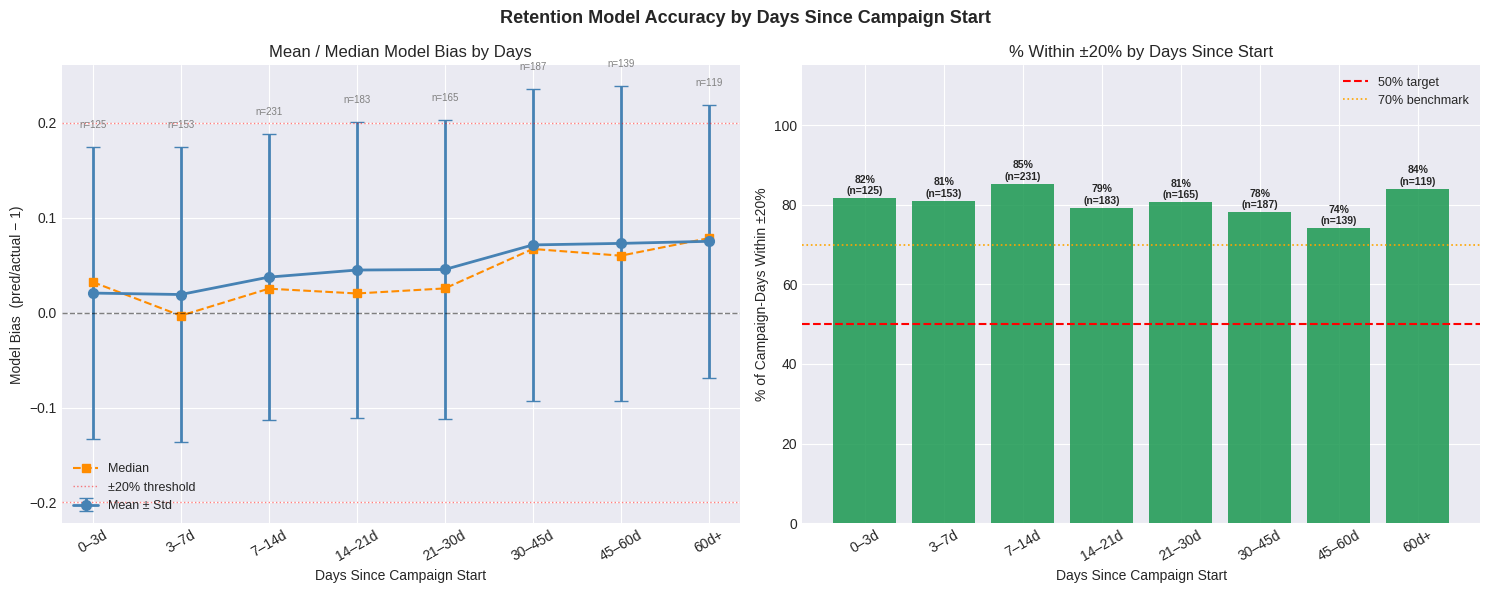

In [13]:
day_bins   = [0, 3, 7, 14, 21, 30, 45, 60, np.inf]
day_labels = ['0–3d', '3–7d', '7–14d', '14–21d', '21–30d', '30–45d', '45–60d', '60d+']

df_filtered['day_bin'] = pd.cut(
    df_filtered['days_since_start'],
    bins=day_bins, labels=day_labels, right=False
)

day_summary = df_filtered.groupby('day_bin', observed=True)['daily_model_bias'].agg(
    median='median',
    mean='mean',
    std='std',
    count='count',
    pct_within_threshold=lambda x: (x.abs() < BIAS_THRESHOLD).mean() * 100
).reset_index()

print(f'📊 Model Bias by Days Since Campaign Start (threshold = ±{BIAS_THRESHOLD*100:.0f}%):')
print(day_summary.to_string(index=False, float_format='{:.4f}'.format))

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
fig.suptitle('Retention Model Accuracy by Days Since Campaign Start', fontsize=13, fontweight='bold')

ax1 = axes[0]
ax1.errorbar(
    day_summary['day_bin'].astype(str),
    day_summary['mean'],
    yerr=day_summary['std'],
    fmt='o-', color='steelblue', linewidth=2, markersize=7, capsize=5, label='Mean ± Std'
)
ax1.plot(day_summary['day_bin'].astype(str), day_summary['median'],
         's--', color='darkorange', linewidth=1.5, markersize=6, label='Median')
ax1.axhline(0,                color='black', linewidth=1,   linestyle='--', alpha=0.5)
ax1.axhline( BIAS_THRESHOLD,  color='red',   linewidth=1,   linestyle=':',  alpha=0.5, label=f'±{BIAS_THRESHOLD*100:.0f}% threshold')
ax1.axhline(-BIAS_THRESHOLD,  color='red',   linewidth=1,   linestyle=':',  alpha=0.5)
# Annotate n
for i, row in enumerate(day_summary.itertuples()):
    ax1.annotate(f'n={int(row.count)}', xy=(i, row.mean + row.std + 0.02),
                 ha='center', fontsize=7, color='gray')
ax1.set_title('Mean / Median Model Bias by Days')
ax1.set_xlabel('Days Since Campaign Start')
ax1.set_ylabel('Model Bias  (pred/actual − 1)')
ax1.tick_params(axis='x', rotation=30)
ax1.legend(fontsize=9)

ax2 = axes[1]
colors = ['#d73027' if v < 50 else '#fee090' if v < 70 else '#1a9850' for v in day_summary['pct_within_threshold']]
bars = ax2.bar(day_summary['day_bin'].astype(str), day_summary['pct_within_threshold'], color=colors, alpha=0.85)
ax2.axhline(50, color='red',    linewidth=1.5, linestyle='--', label='50% target')
ax2.axhline(70, color='orange', linewidth=1.2, linestyle=':',  label='70% benchmark')
for bar, row in zip(bars, day_summary.itertuples()):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
             f'{row.pct_within_threshold:.0f}%\n(n={int(row.count)})',
             ha='center', va='bottom', fontsize=7.5, fontweight='bold')
ax2.set_title(f'% Within ±{BIAS_THRESHOLD*100:.0f}% by Days Since Start')
ax2.set_xlabel('Days Since Campaign Start')
ax2.set_ylabel(f'% of Campaign-Days Within ±{BIAS_THRESHOLD*100:.0f}%')
ax2.set_ylim(0, 115)
ax2.tick_params(axis='x', rotation=30)
ax2.legend(fontsize=9)

plt.tight_layout()
plt.show()


## Step 7 — Per-Game Deep-Dive: Top 20 Games by Spend

For each of the top 20 games, plots:
1. Daily installs + cumulative installs (left y-axis)
2. Model bias MA7 (right y-axis)

This makes it easy to see the individual learning trajectory and when bias stabilizes.


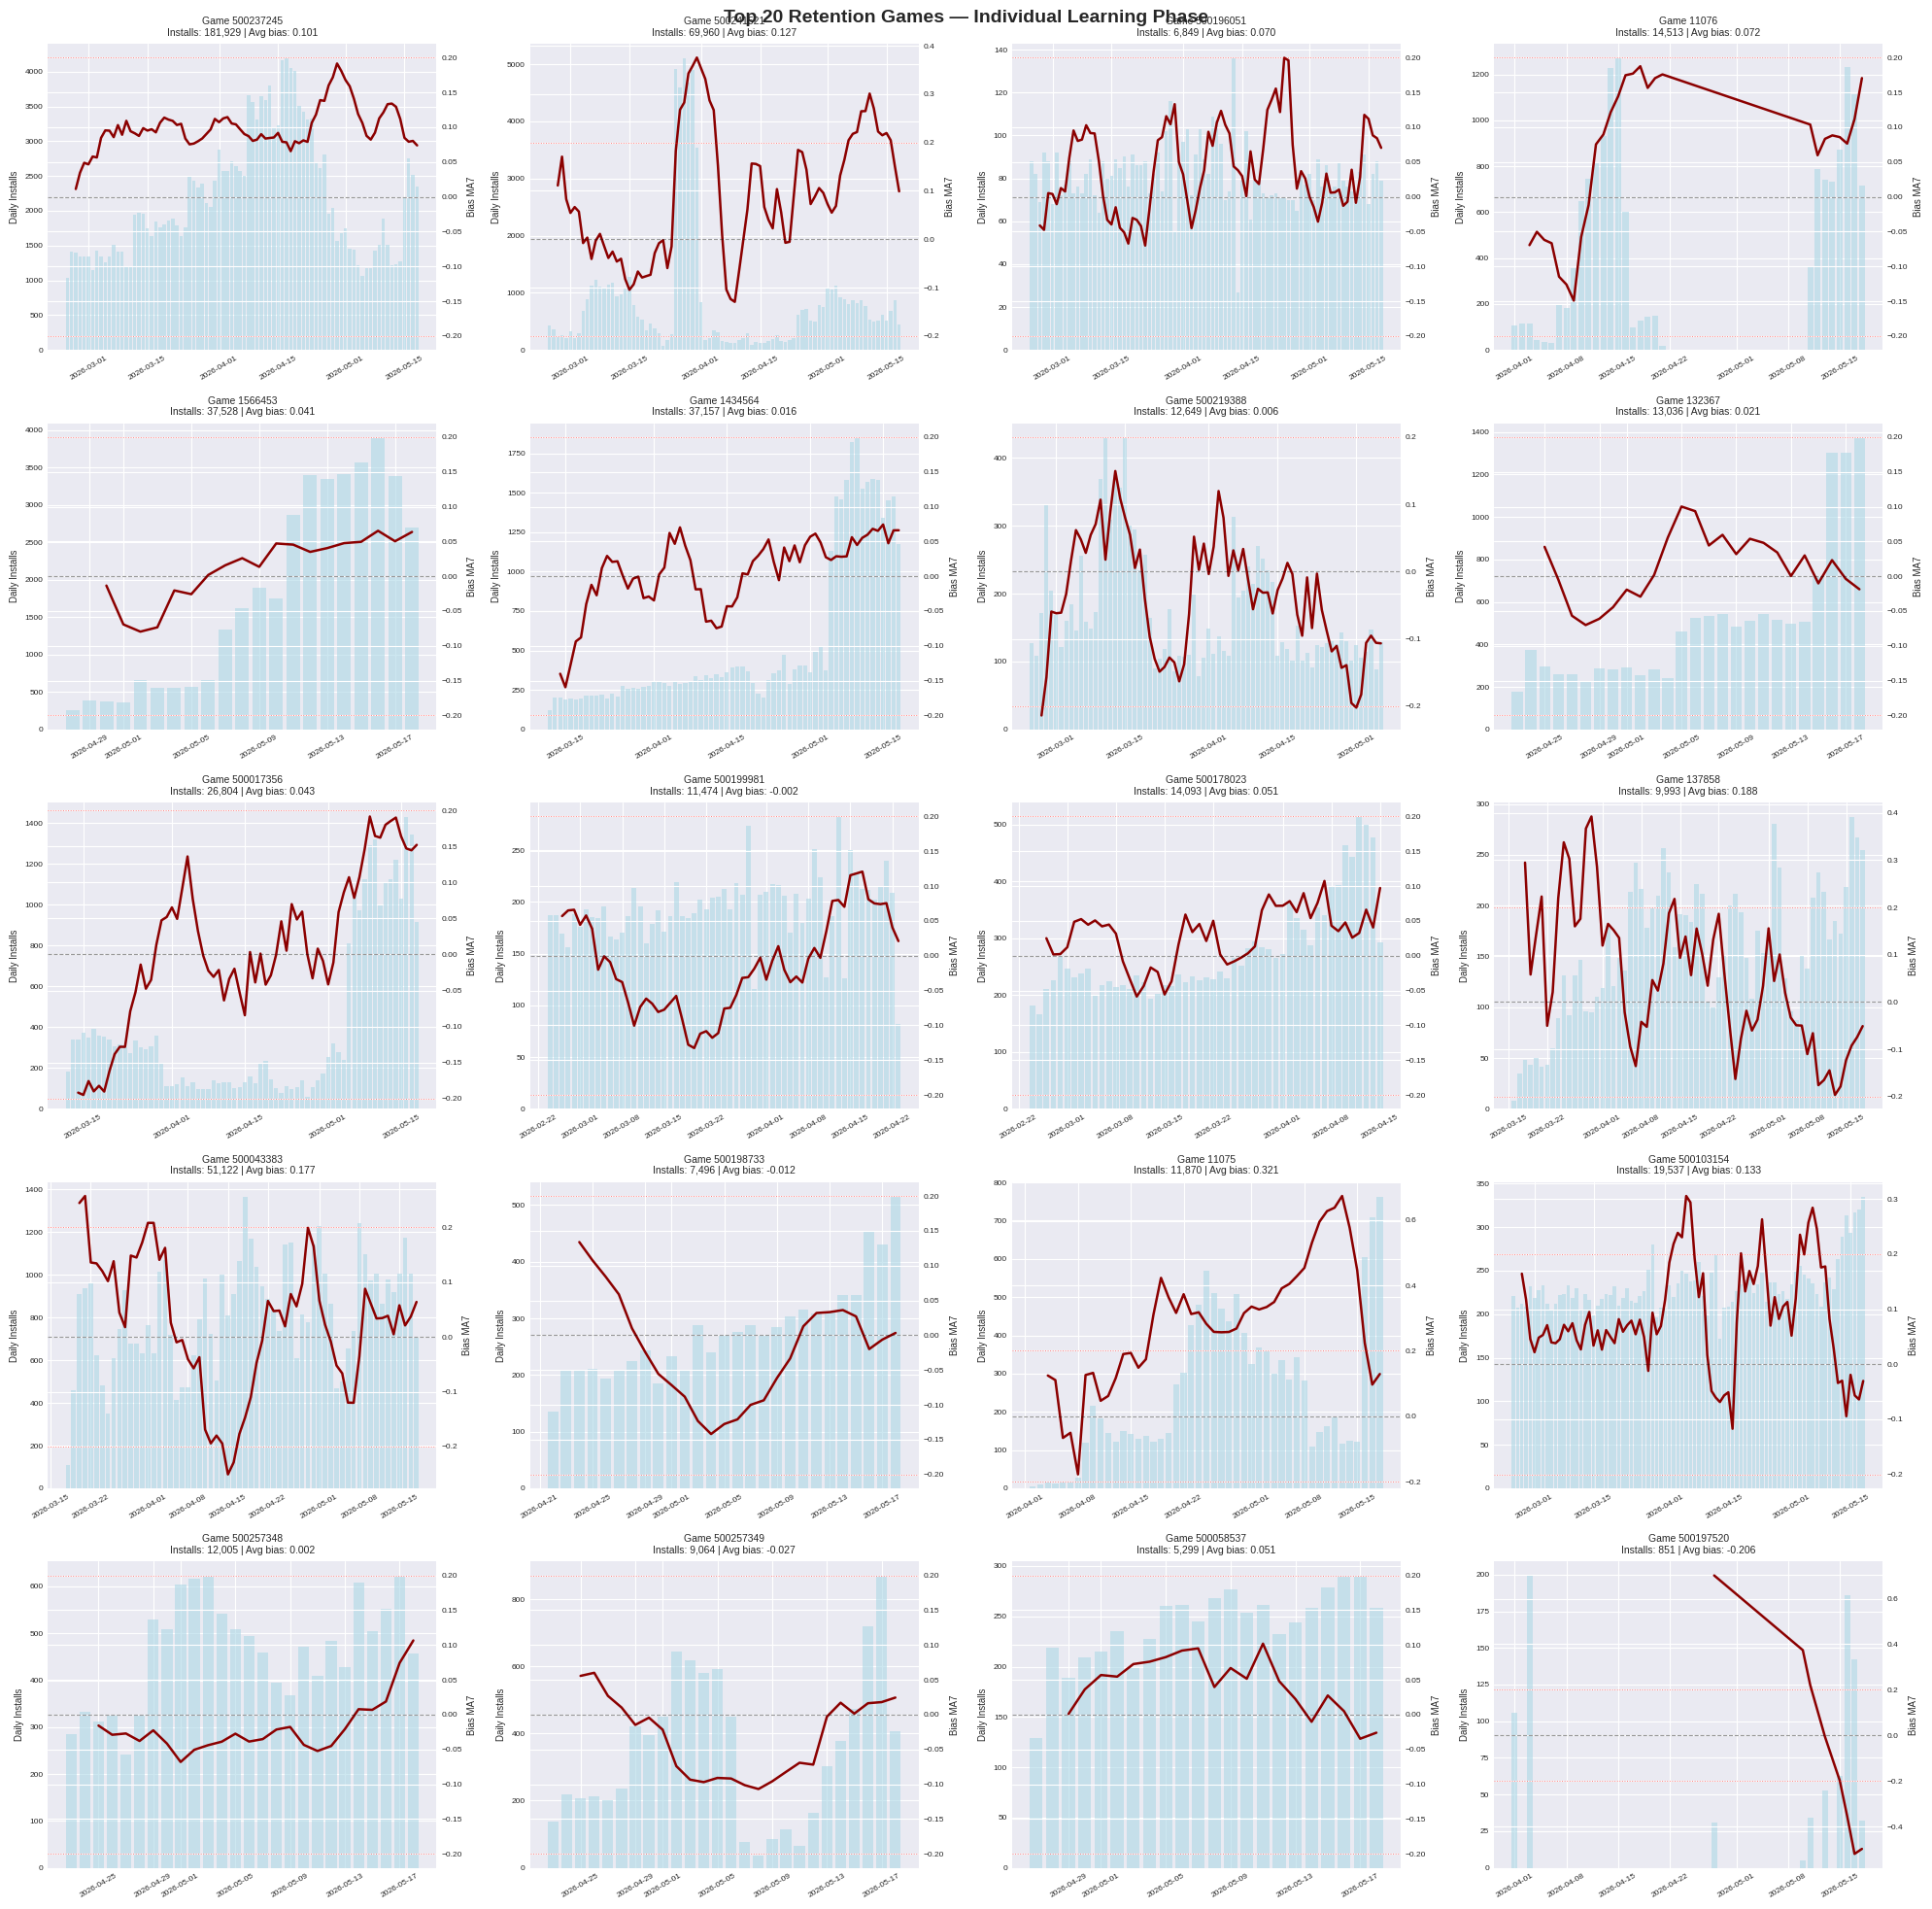

In [14]:
# Select top 20 games by total spend from the game_list_df
top_games = game_list_df.head(20)['target_game_id'].astype(str).tolist()
df_top = df[df['game_id'].isin(top_games)].copy()

n_games = len(top_games)
n_cols = 4
n_rows = int(np.ceil(n_games / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, n_rows * 4))
fig.suptitle('Top 20 Retention Games — Individual Learning Phase', fontsize=14, fontweight='bold')
axes_flat = axes.flatten()

for idx, game_id in enumerate(top_games):
    game_data = df_top[df_top['game_id'] == game_id].sort_values('date')
    ax = axes_flat[idx]

    if len(game_data) < 3:
        ax.set_title(f'Game {game_id}\n(insufficient data)', fontsize=8)
        ax.axis('off')
        continue

    # Install bars
    ax.bar(game_data['date'], game_data['daily_installs'], color='lightblue', alpha=0.6, label='Daily installs')
    ax.set_ylabel('Daily Installs', fontsize=7)

    # Bias line on twin axis
    ax2 = ax.twinx()
    valid = game_data['model_bias_ma7'].notna()
    if valid.sum() >= 3:
        ax2.plot(game_data.loc[valid, 'date'], game_data.loc[valid, 'model_bias_ma7'],
                 color='darkred', linewidth=1.8, label='Bias MA7')
    ax2.axhline(0, color='black', linewidth=0.8, linestyle='--', alpha=0.4)
    ax2.axhline(0.2, color='red', linewidth=0.7, linestyle=':', alpha=0.5)
    ax2.axhline(-0.2, color='red', linewidth=0.7, linestyle=':', alpha=0.5)
    ax2.set_ylabel('Bias MA7', fontsize=7)

    total_installs = game_data['cumulative_installs'].max()
    avg_bias = game_data['daily_model_bias'].mean()
    ax.set_title(f'Game {game_id}\nInstalls: {total_installs:,.0f} | Avg bias: {avg_bias:.3f}', fontsize=7.5)
    ax.tick_params(axis='x', labelsize=6, rotation=30)
    ax.tick_params(axis='y', labelsize=6)
    ax2.tick_params(axis='y', labelsize=6)

# Hide unused axes
for idx in range(n_games, len(axes_flat)):
    axes_flat[idx].axis('off')

plt.tight_layout()
plt.show()


## Step 8 — Learning Phase Threshold Analysis

For each game, identifies the number of cumulative installs at which the model bias
first stabilizes within ±20%. Determines the distribution of this threshold across
all games to recommend a learning phase install target.


📊 Stabilization Analysis  (entry: 3-day streak, persistence: ≥70% of ≥7 days)
   Games with sufficient data : 57
   Stabilized                 : 35  (61.4%)
   Still learning / too short : 22

   Cumulative installs at stabilization:
     P25: 398
     Median: 655
     P75: 1,026
     P90: 2,430

   Cumulative retained D7 at stabilization:
     P25: 68
     Median: 93
     P75: 148
     P90: 332

   Days since start at stabilization:
     P25: 2.0 days
     Median: 2.0 days
     P75: 2.0 days
     P90: 6.4 days


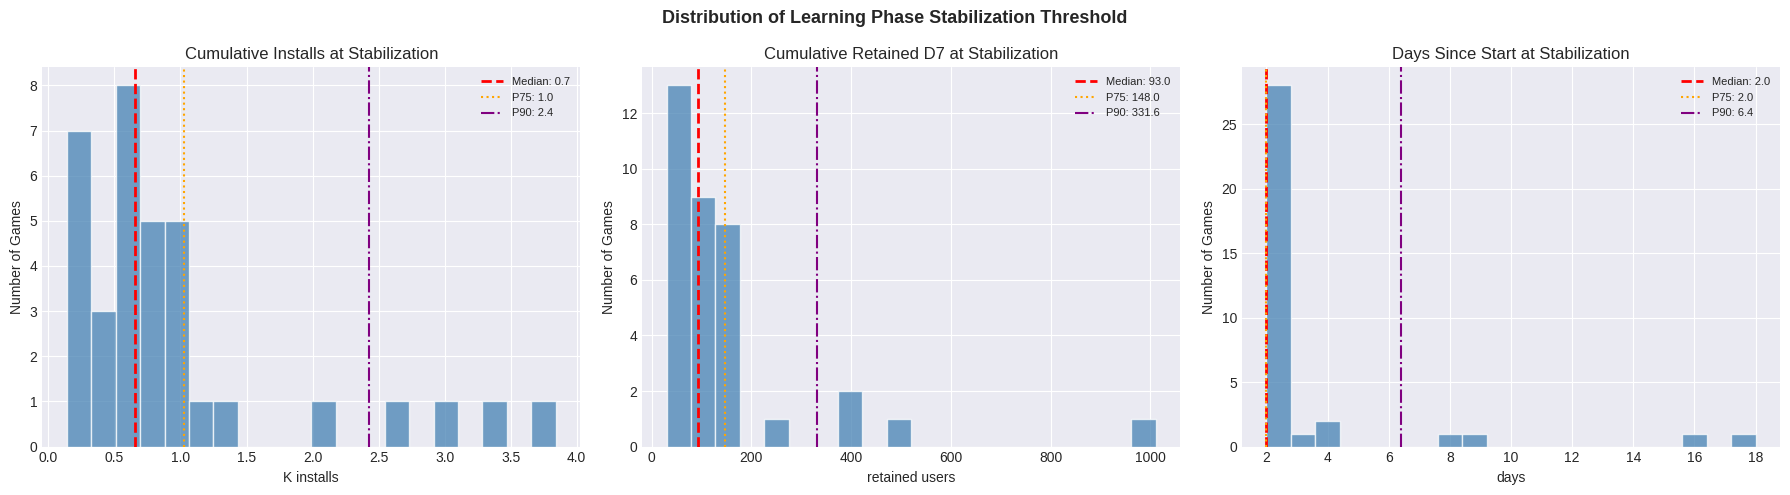

In [15]:
def find_stabilization_point(game_df):
    """
    Returns the first point where MA7 bias enters ±BIAS_THRESHOLD AND stays there.

    Entry condition  : STREAK_DAYS consecutive days inside ±BIAS_THRESHOLD
    Persistence check: of the days from entry onwards, at least POST_STABLE_MIN_PCT
                       must remain inside ±BIAS_THRESHOLD, AND there must be at least
                       POST_STABLE_MIN_DAYS such days (so we don't validate on just 1–2 days).
    """
    g = game_df.sort_values('date').reset_index(drop=True)
    g['within'] = g['model_bias_ma7'].abs() < BIAS_THRESHOLD

    for i in range(len(g) - STREAK_DAYS + 1):
        # Check streak entry
        if not all(g.loc[i:i + STREAK_DAYS - 1, 'within']):
            continue
        # Persistence: look at all days from entry to end of series
        post = g.loc[i:, 'within']
        if len(post) < POST_STABLE_MIN_DAYS:
            continue
        if post.mean() >= POST_STABLE_MIN_PCT:
            return {
                'game_id'                  : g['game_id'].iloc[0],
                'stabilization_installs'   : g.loc[i, 'cumulative_installs'],
                'stabilization_retained_d7': g.loc[i, 'cumulative_retained_d7'],
                'stabilization_day'        : g.loc[i, 'days_since_start'],
                'stabilization_date'       : g.loc[i, 'date'],
                'post_entry_pct_within'    : post.mean() * 100,
                'post_entry_days'          : len(post),
                'total_installs'           : g['cumulative_installs'].max(),
                'total_retained_d7'        : g['cumulative_retained_d7'].max(),
                'days_tracked'             : g['days_since_start'].max(),
                'stabilized'               : True,
            }

    return {
        'game_id'                  : g['game_id'].iloc[0],
        'stabilization_installs'   : np.nan,
        'stabilization_retained_d7': np.nan,
        'stabilization_day'        : np.nan,
        'stabilization_date'       : pd.NaT,
        'post_entry_pct_within'    : np.nan,
        'post_entry_days'          : np.nan,
        'total_installs'           : g['cumulative_installs'].max(),
        'total_retained_d7'        : g['cumulative_retained_d7'].max(),
        'days_tracked'             : g['days_since_start'].max(),
        'stabilized'               : False,
    }

# Use df_valid (same retention filter as bucket analysis, but no outlier clip —
# we want real install counts, not display-clipped values)
df_valid_bias = df_valid[df_valid['model_bias_ma7'].notna()].copy()
stabilization_results = df_valid_bias.groupby('game_id', group_keys=False).apply(find_stabilization_point)
stab_df = pd.DataFrame(list(stabilization_results))

stab_success = stab_df[stab_df['stabilized']]
stab_fail    = stab_df[~stab_df['stabilized']]

print(f'📊 Stabilization Analysis  (entry: {STREAK_DAYS}-day streak, persistence: ≥{POST_STABLE_MIN_PCT*100:.0f}% of ≥{POST_STABLE_MIN_DAYS} days)')
print(f'   Games with sufficient data : {len(stab_df)}')
print(f'   Stabilized                 : {len(stab_success)}  ({len(stab_success)/len(stab_df)*100:.1f}%)')
print(f'   Still learning / too short : {len(stab_fail)}')

if len(stab_success) > 0:
    print(f'\n   Cumulative installs at stabilization:')
    for pct, label in [(0.25,"P25"), (0.50,"Median"), (0.75,"P75"), (0.90,"P90")]:
        v = stab_success['stabilization_installs'].quantile(pct)
        print(f'     {label}: {v:,.0f}')

    print(f'\n   Cumulative retained D7 at stabilization:')
    for pct, label in [(0.25,"P25"), (0.50,"Median"), (0.75,"P75"), (0.90,"P90")]:
        v = stab_success['stabilization_retained_d7'].quantile(pct)
        print(f'     {label}: {v:,.0f}')

    print(f'\n   Days since start at stabilization:')
    for pct, label in [(0.25,"P25"), (0.50,"Median"), (0.75,"P75"), (0.90,"P90")]:
        v = stab_success['stabilization_day'].quantile(pct)
        print(f'     {label}: {v:.1f} days')

# ── Plot distribution ─────────────────────────────────────────────────────────
if len(stab_success) >= 5:
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    fig.suptitle('Distribution of Learning Phase Stabilization Threshold', fontsize=13, fontweight='bold')

    for ax, col, xlabel, unit in [
        (axes[0], 'stabilization_installs',    'Cumulative Installs at Stabilization', 'K installs'),
        (axes[1], 'stabilization_retained_d7', 'Cumulative Retained D7 at Stabilization', 'retained users'),
        (axes[2], 'stabilization_day',         'Days Since Start at Stabilization', 'days'),
    ]:
        data = stab_success[col].dropna()
        divisor = 1000 if unit == 'K installs' else 1
        ax.hist(data / divisor, bins=20, color='steelblue', alpha=0.75, edgecolor='white')
        med = data.median() / divisor
        p75 = data.quantile(0.75) / divisor
        p90 = data.quantile(0.90) / divisor
        ax.axvline(med, color='red',    linewidth=2,   linestyle='--', label=f'Median: {med:.1f}')
        ax.axvline(p75, color='orange', linewidth=1.5, linestyle=':',  label=f'P75: {p75:.1f}')
        ax.axvline(p90, color='purple', linewidth=1.5, linestyle='-.',  label=f'P90: {p90:.1f}')
        ax.set_title(xlabel)
        ax.set_xlabel(unit)
        ax.set_ylabel('Number of Games')
        ax.legend(fontsize=8)

    plt.tight_layout()
    plt.show()
else:
    print('⚠️  Insufficient stabilized games for distribution plot')


## Step 8b — Post-Stabilization Drift Analysis

After a game reaches the stabilization point, does the model **stay** stable?
Compares pre- vs post-threshold bias quality to validate that the threshold is meaningful.


📊 Pre vs Post Stabilization — across 35 stabilized games

  PRE-stabilization  (n_games=7):
    Mean bias (abs): 0.2699
    Pct within ±20%: 7.1%

  POST-stabilization (n_games=35):
    Mean bias (abs): 0.0368
    Pct within ±20%: 96.9%


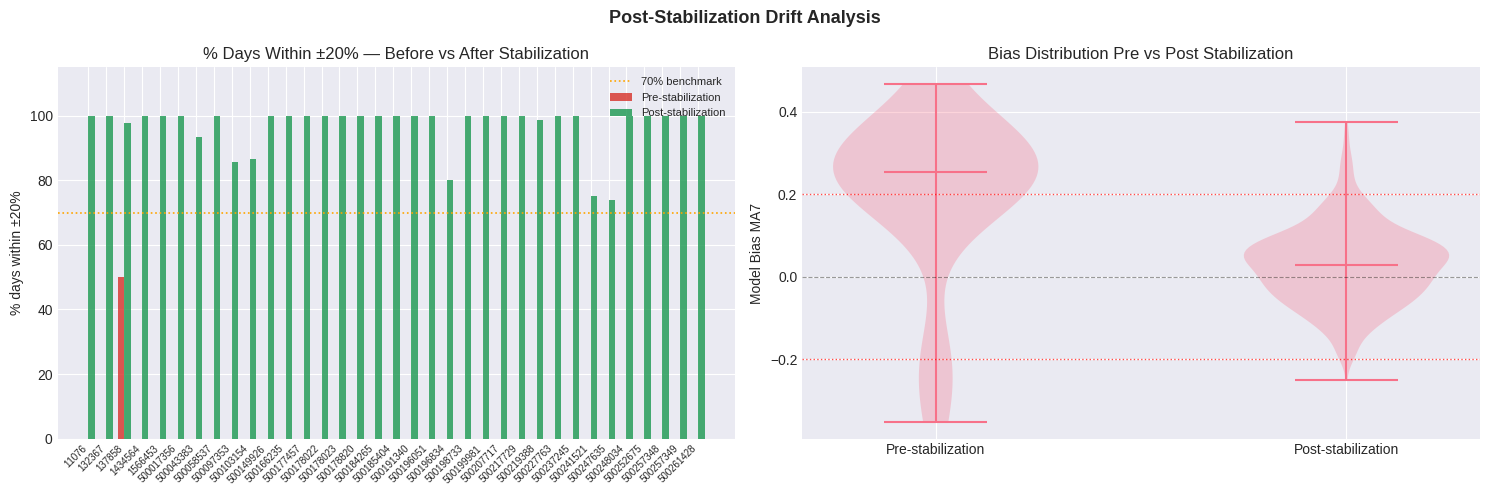

In [16]:
if len(stab_success) < 3:
    print('⚠️  Not enough stabilized games for drift analysis — skipping.')
else:
    # Tag each game-day as pre/post stabilization
    stab_lookup = stab_success.set_index('game_id')[['stabilization_date', 'stabilization_installs', 'stabilization_retained_d7']]
    df_drift = df_valid_bias[df_valid_bias['game_id'].isin(stab_success['game_id'])].copy()
    df_drift = df_drift.join(stab_lookup, on='game_id')
    df_drift['phase'] = np.where(df_drift['date'] < df_drift['stabilization_date'], 'Pre-stabilization', 'Post-stabilization')

    # Per-game pre/post summary
    drift_summary = df_drift.groupby(['game_id', 'phase'])['model_bias_ma7'].agg(
        mean='mean',
        std='std',
        pct_within=lambda x: (x.abs() < BIAS_THRESHOLD).mean() * 100,
        n='count'
    ).reset_index()

    pre  = drift_summary[drift_summary['phase'] == 'Pre-stabilization']
    post = drift_summary[drift_summary['phase'] == 'Post-stabilization']

    print(f'📊 Pre vs Post Stabilization — across {len(stab_success)} stabilized games')
    print(f'\n  PRE-stabilization  (n_games={len(pre)}):')
    print(f'    Mean bias (abs): {pre["mean"].abs().mean():.4f}')
    print(f'    Pct within ±{BIAS_THRESHOLD*100:.0f}%: {pre["pct_within"].mean():.1f}%')
    print(f'\n  POST-stabilization (n_games={len(post)}):')
    print(f'    Mean bias (abs): {post["mean"].abs().mean():.4f}')
    print(f'    Pct within ±{BIAS_THRESHOLD*100:.0f}%: {post["pct_within"].mean():.1f}%')

    # ── Plot: per-game pre/post % within threshold ───────────────────────────
    fig, axes = plt.subplots(1, 2, figsize=(15, 5))
    fig.suptitle('Post-Stabilization Drift Analysis', fontsize=13, fontweight='bold')

    ax1 = axes[0]
    pre_vals  = pre.set_index('game_id')['pct_within'].reindex(stab_success['game_id'])
    post_vals = post.set_index('game_id')['pct_within'].reindex(stab_success['game_id'])
    x = np.arange(len(stab_success))
    w = 0.35
    ax1.bar(x - w/2, pre_vals.values,  w, label='Pre-stabilization',  color='#d73027', alpha=0.8)
    ax1.bar(x + w/2, post_vals.values, w, label='Post-stabilization', color='#1a9850', alpha=0.8)
    ax1.axhline(70, color='orange', linewidth=1.2, linestyle=':', label='70% benchmark')
    ax1.set_xticks(x)
    ax1.set_xticklabels(stab_success['game_id'].values, rotation=45, ha='right', fontsize=7)
    ax1.set_title(f'% Days Within ±{BIAS_THRESHOLD*100:.0f}% — Before vs After Stabilization')
    ax1.set_ylabel(f'% days within ±{BIAS_THRESHOLD*100:.0f}%')
    ax1.set_ylim(0, 115)
    ax1.legend(fontsize=8)

    ax2 = axes[1]
    # Population-level: bias distribution pre vs post (violin)
    pre_all  = df_drift[df_drift['phase'] == 'Pre-stabilization' ]['model_bias_ma7'].dropna()
    post_all = df_drift[df_drift['phase'] == 'Post-stabilization']['model_bias_ma7'].dropna()
    ax2.violinplot([pre_all, post_all], positions=[1, 2], showmedians=True)
    ax2.axhline( BIAS_THRESHOLD, color='red', linewidth=1, linestyle=':', alpha=0.7)
    ax2.axhline(-BIAS_THRESHOLD, color='red', linewidth=1, linestyle=':', alpha=0.7)
    ax2.axhline(0, color='black', linewidth=0.8, linestyle='--', alpha=0.4)
    ax2.set_xticks([1, 2])
    ax2.set_xticklabels(['Pre-stabilization', 'Post-stabilization'])
    ax2.set_title('Bias Distribution Pre vs Post Stabilization')
    ax2.set_ylabel('Model Bias MA7')

    plt.tight_layout()
    plt.show()


## Step 8c — Sensitivity Analysis: Eligibility Threshold Candidates

For each candidate threshold (installs or retained D7), computes what % of campaign-days
*after* that threshold are within ±20% bias. This is the core table to justify an eligibility rule.


📊 Sensitivity Analysis — days above threshold  (bias = ±20%)

  By Cumulative Installs:
threshold pct_within_threshold mean_bias  n_game_days  n_games
      200                90.9%    0.0449         1340       56
      500                91.2%    0.0452         1279       47
    1,000                90.8%    0.0467         1174       41
    2,000                90.6%    0.0505         1015       37
    5,000                90.5%    0.0591          707       26

  By Cumulative Retained D7:
threshold pct_within_threshold mean_bias  n_game_days  n_games
       50                91.3%    0.0432         1319       55
      100                91.5%    0.0425         1243       45
      200                92.0%    0.0436         1106       41
      500                91.6%    0.0525          846       31
    1,000                91.5%    0.0654          598       21


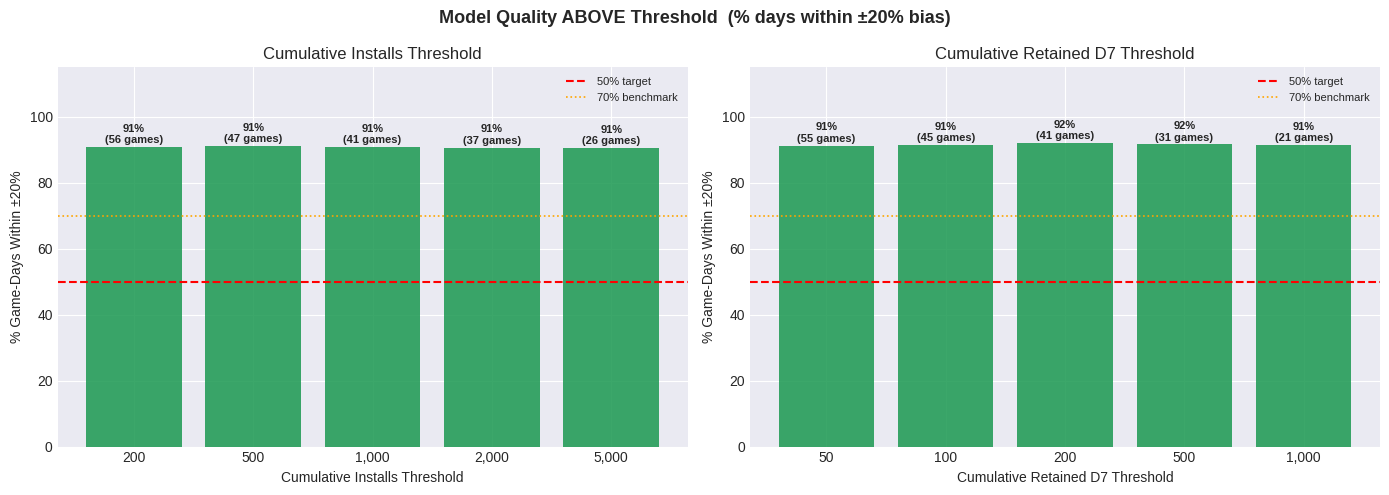


💡 First threshold reaching ≥70% stability:
   Installs : ≥200 cumulative installs
   Retained : ≥50 cumulative retained D7 users


In [17]:
def sensitivity_row(df_src, col, threshold):
    """For a given threshold on `col`, compute bias quality for days above that threshold."""
    above = df_src[df_src[col] >= threshold]
    if len(above) == 0:
        return None
    pct_within  = (above['model_bias_ma7'].abs() < BIAS_THRESHOLD).mean() * 100
    mean_bias   = above['model_bias_ma7'].mean()
    n_game_days = len(above)
    n_games     = above['game_id'].nunique()
    return dict(threshold=threshold, pct_within_threshold=pct_within,
                mean_bias=mean_bias, n_game_days=n_game_days, n_games=n_games)

df_sens = df_valid_bias.copy()  # consistent filter with stabilization analysis

rows_installs = [sensitivity_row(df_sens, 'cumulative_installs', t)
                 for t in SENSITIVITY_THRESHOLDS_INSTALLS]
rows_retained = [sensitivity_row(df_sens, 'cumulative_retained_d7', t)
                 for t in SENSITIVITY_THRESHOLDS_RETAINED]

sens_installs = pd.DataFrame([r for r in rows_installs if r])
sens_retained = pd.DataFrame([r for r in rows_retained if r])

print(f'📊 Sensitivity Analysis — days above threshold  (bias = ±{BIAS_THRESHOLD*100:.0f}%)')
print('\n  By Cumulative Installs:')
print(sens_installs.to_string(index=False,
      formatters={'pct_within_threshold': '{:.1f}%'.format,
                  'mean_bias': '{:.4f}'.format,
                  'threshold': '{:,.0f}'.format}))
print('\n  By Cumulative Retained D7:')
print(sens_retained.to_string(index=False,
      formatters={'pct_within_threshold': '{:.1f}%'.format,
                  'mean_bias': '{:.4f}'.format,
                  'threshold': '{:,.0f}'.format}))

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle(f'Model Quality ABOVE Threshold  (% days within ±{BIAS_THRESHOLD*100:.0f}% bias)', fontsize=13, fontweight='bold')

for ax, sens, xlabel in [
    (axes[0], sens_installs, 'Cumulative Installs Threshold'),
    (axes[1], sens_retained, 'Cumulative Retained D7 Threshold'),
]:
    x_labels = [f'{int(t):,}' for t in sens['threshold']]
    colors = ['#d73027' if v < 50 else '#fee090' if v < 70 else '#1a9850' for v in sens['pct_within_threshold']]
    bars = ax.bar(x_labels, sens['pct_within_threshold'], color=colors, alpha=0.85)
    ax.axhline(50, color='red',    linewidth=1.5, linestyle='--', label='50% target')
    ax.axhline(70, color='orange', linewidth=1.2, linestyle=':',  label='70% benchmark')
    for bar, row in zip(bars, sens.itertuples()):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                f'{row.pct_within_threshold:.0f}%\n({row.n_games} games)',
                ha='center', va='bottom', fontsize=8, fontweight='bold')
    ax.set_title(xlabel)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(f'% Game-Days Within ±{BIAS_THRESHOLD*100:.0f}%')
    ax.set_ylim(0, 115)
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

# ── Recommendation row: first threshold reaching 70% ────────────────────────
print('\n💡 First threshold reaching ≥70% stability:')
hit_install  = sens_installs[sens_installs['pct_within_threshold'] >= 70].head(1)
hit_retained = sens_retained[sens_retained['pct_within_threshold'] >= 70].head(1)
if not hit_install.empty:
    print(f'   Installs : ≥{int(hit_install["threshold"].values[0]):,} cumulative installs')
if not hit_retained.empty:
    print(f'   Retained : ≥{int(hit_retained["threshold"].values[0]):,} cumulative retained D7 users')


## Step 9 — Alpha Game Performance Check

Focuses specifically on the 22 Alpha Test games from the Retention Alpha Test doc,
reporting their model accuracy and learning phase status.


📊 Alpha games found in dataset: 12 / 22

📊 Alpha Game Summary:


,game_id,first_date,last_date,total_installs,total_retained_d7,mean_daily_bias,pct_within_threshold,total_spend,days_tracked,stabilization_installs,stabilization_retained_d7,stabilization_day,stabilized
0,500241521,2026-02-24,2026-05-18,69960,3895,0.126733,55.952381,102779.879041,83,1040.0,88.0,2.0,True
1,500196051,2026-02-24,2026-05-18,6849,2356,0.070420,77.380952,84859.721224,83,239.0,91.0,2.0,True
2,500199981,2026-02-24,2026-04-23,11474,2828,-0.001665,91.525424,58516.008368,58,543.0,125.0,2.0,True
3,500103154,2026-02-24,2026-05-18,19537,1405,0.133081,60.714286,42343.146827,83,640.0,45.0,2.0,True
4,500149926,2026-02-24,2026-04-02,10004,2692,0.120782,81.578947,17667.827492,37,893.0,265.0,2.0,True
5,500166235,2026-02-24,2026-03-19,26312,4850,-0.017005,79.166667,10184.735719,23,1035.0,143.0,4.0,True
6,500177457,2026-02-24,2026-05-17,2806,786,0.191507,51.470588,6439.519666,82,162.0,56.0,2.0,True
7,500097353,2026-02-24,2026-03-20,1180,212,0.171019,40.000000,2460.766488,24,447.0,71.0,9.0,True
8,500232905,2026-02-24,2026-02-26,346,101,-0.042511,100.000000,1970.095629,2,NaN,NaN,NaN,False
9,500238832,2026-04-01,2026-04-08,2519,533,0.079090,100.000000,1878.981506,7,NaN,NaN,NaN,False


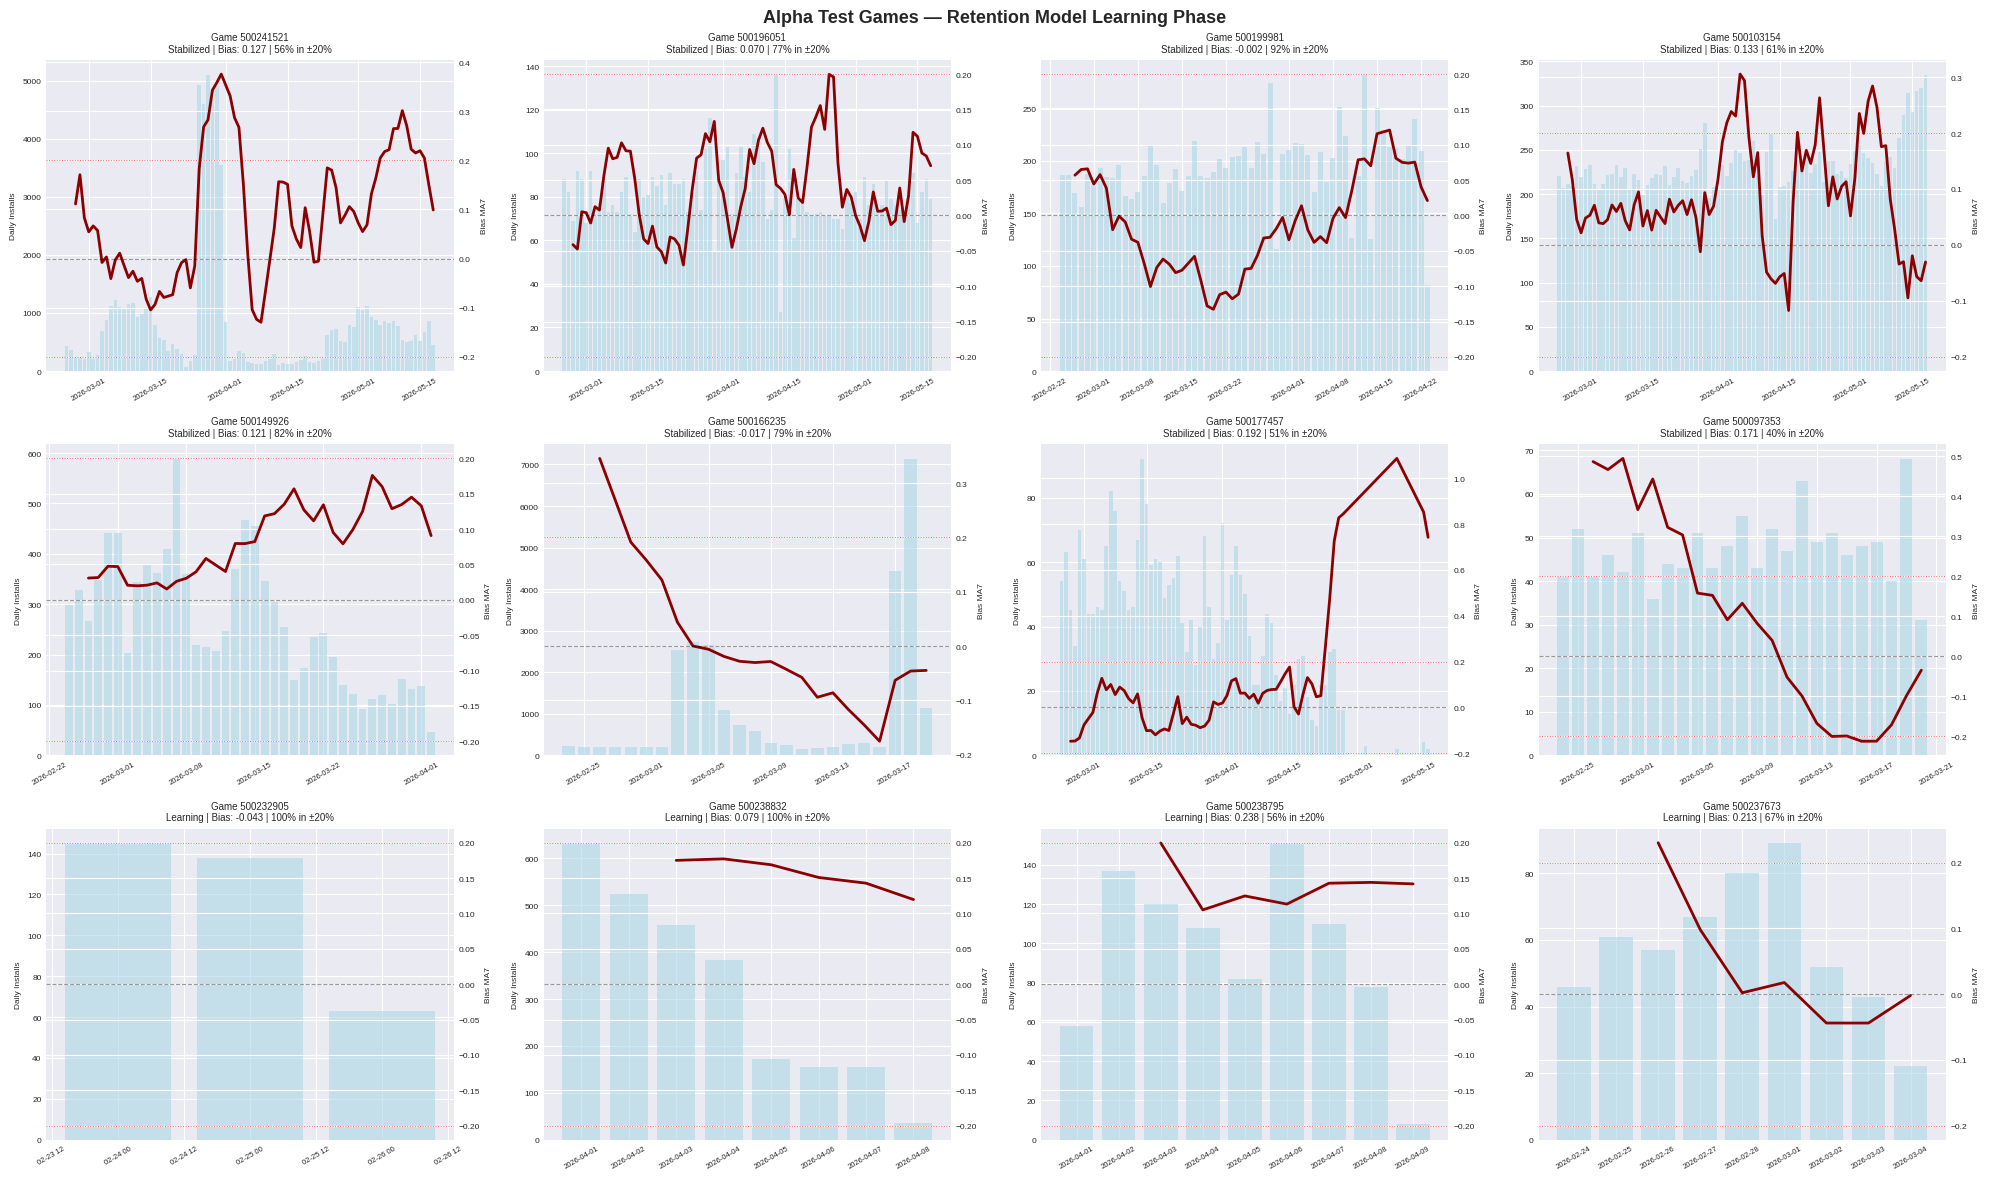

In [18]:
ALPHA_GAME_IDS = [
    500085499, 500090629, 500097353, 500103154, 500149926,
    500166235, 500177457, 500195059, 500196051, 500199981,
    500206220, 500207188, 500209790, 500215793, 500232905,
    500237673, 500237674, 500238795, 500238832, 500241521,
    500241524, 500242067
]
alpha_game_ids_str = [str(g) for g in ALPHA_GAME_IDS]

df_alpha  = df[df['game_id'].isin(alpha_game_ids_str)].copy()
found_alpha = df_alpha['game_id'].nunique()
print(f'📊 Alpha games found in dataset: {found_alpha} / {len(ALPHA_GAME_IDS)}')

if found_alpha == 0:
    print('⚠️  No Alpha games found. They may not have sufficient D7 data yet.')
else:
    alpha_summary = df_alpha.groupby('game_id').agg(
        first_date=('date', 'min'),
        last_date=('date', 'max'),
        total_installs=('daily_installs', 'sum'),
        total_retained_d7=('daily_retained_d7', 'sum'),
        mean_daily_bias=('daily_model_bias', 'mean'),
        pct_within_threshold=('daily_model_bias', lambda x: (x.abs() < BIAS_THRESHOLD).mean() * 100),
        total_spend=('daily_spend', 'sum'),
        days_tracked=('days_since_start', 'max')
    ).reset_index()

    alpha_summary = alpha_summary.merge(
        stab_df[['game_id', 'stabilization_installs', 'stabilization_retained_d7',
                 'stabilization_day', 'stabilized']],
        on='game_id', how='left'
    ).sort_values('total_spend', ascending=False).reset_index(drop=True)

    print('\n📊 Alpha Game Summary:')
    display(alpha_summary)

    # ── Per-game plots ────────────────────────────────────────────────────────
    n_alpha  = len(alpha_summary)
    n_cols_a = 4
    n_rows_a = int(np.ceil(n_alpha / n_cols_a))

    fig, axes = plt.subplots(n_rows_a, n_cols_a, figsize=(20, n_rows_a * 4))
    fig.suptitle('Alpha Test Games — Retention Model Learning Phase', fontsize=13, fontweight='bold')
    axes_flat = axes.flatten() if n_alpha > 1 else [axes]

    for i, row in enumerate(alpha_summary.itertuples()):   # fixed: simple enumerate, no O(n²) index lookup
        if i >= len(axes_flat):
            break
        ax  = axes_flat[i]
        gd  = df_alpha[df_alpha['game_id'] == row.game_id].sort_values('date')

        ax.bar(gd['date'], gd['daily_installs'], color='lightblue', alpha=0.6)
        ax2 = ax.twinx()
        valid = gd['model_bias_ma7'].notna()
        if valid.sum() >= 2:
            ax2.plot(gd.loc[valid, 'date'], gd.loc[valid, 'model_bias_ma7'],
                     color='darkred', linewidth=2)
        ax2.axhline(0,               color='black', linewidth=0.8, linestyle='--', alpha=0.4)
        ax2.axhline( BIAS_THRESHOLD, color='red',   linewidth=0.7, linestyle=':',  alpha=0.6)
        ax2.axhline(-BIAS_THRESHOLD, color='red',   linewidth=0.7, linestyle=':',  alpha=0.6)

        stab_status = 'Stabilized' if row.stabilized else 'Learning'
        ax.set_title(
            f'Game {row.game_id}\n{stab_status} | Bias: {row.mean_daily_bias:.3f} | {row.pct_within_threshold:.0f}% in ±{BIAS_THRESHOLD*100:.0f}%',
            fontsize=7
        )
        ax.tick_params(axis='x', labelsize=5.5, rotation=30)
        ax.tick_params(axis='y', labelsize=6)
        ax2.tick_params(axis='y', labelsize=6)
        ax.set_ylabel('Daily Installs', fontsize=6)
        ax2.set_ylabel('Bias MA7',      fontsize=6)

    for i in range(n_alpha, len(axes_flat)):
        axes_flat[i].axis('off')

    plt.tight_layout()
    plt.show()


## Step 10 — Summary & Learning Phase Recommendation


In [19]:
print('=' * 70)
print('RETENTION CAMPAIGN — LEARNING PHASE ANALYSIS SUMMARY')
print('=' * 70)
print(f'\nAnalysis window  : {ANALYSIS_START_DATE} to {df["date"].max().date()}')
print(f'Games analyzed   : {df["game_id"].nunique()}')
print(f'Total rows       : {len(df):,}')

print('\n--- OVERALL MODEL ACCURACY ---')
overall_bias    = (df['daily_ret_d7_prob_sum'].sum() / df['daily_retained_d7'].sum()) - 1
overall_pct_thr = (df['daily_model_bias'].abs() < BIAS_THRESHOLD).mean() * 100
print(f'Overall model bias (pred/actual − 1) : {overall_bias:.4f}')
print(f'Campaign-days within ±{BIAS_THRESHOLD*100:.0f}%           : {overall_pct_thr:.1f}%  (target ≥50%)')

print('\n--- STABILIZATION THRESHOLD (persistence-validated) ---')
if len(stab_success) > 0:
    med_inst = stab_success['stabilization_installs'].median()
    p75_inst = stab_success['stabilization_installs'].quantile(0.75)
    med_ret  = stab_success['stabilization_retained_d7'].median()
    p75_ret  = stab_success['stabilization_retained_d7'].quantile(0.75)
    med_day  = stab_success['stabilization_day'].median()
    p75_day  = stab_success['stabilization_day'].quantile(0.75)
    print(f'Games stabilized : {len(stab_success)} / {len(stab_df)}  ({len(stab_success)/len(stab_df)*100:.0f}%)')
    print(f'Installs         : median {med_inst:,.0f}   P75 {p75_inst:,.0f}')
    print(f'Retained D7      : median {med_ret:,.0f}    P75 {p75_ret:,.0f}')
    print(f'Days             : median {med_day:.0f}      P75 {p75_day:.0f}')
else:
    print('⚠️  Insufficient data to compute persistence-validated stabilization.')

print('\n--- SENSITIVITY ANALYSIS (% days above threshold within ±20%) ---')
if 'sens_installs' in dir() and len(sens_installs) > 0:
    print('  Cumulative Installs threshold → % within ±20%:')
    for _, row in sens_installs.iterrows():
        print(f'    ≥{int(row["threshold"]):>6,} installs : {row["pct_within_threshold"]:.1f}%  ({row["n_games"]} games, {int(row["n_game_days"])} game-days)')
if 'sens_retained' in dir() and len(sens_retained) > 0:
    print('  Cumulative Retained D7 threshold → % within ±20%:')
    for _, row in sens_retained.iterrows():
        print(f'    ≥{int(row["threshold"]):>5,} retained D7 : {row["pct_within_threshold"]:.1f}%  ({row["n_games"]} games, {int(row["n_game_days"])} game-days)')

print('\n--- ALPHA TEST CAMPAIGNS ---')
if found_alpha > 0:
    alpha_pct = (df_alpha['daily_model_bias'].abs() < BIAS_THRESHOLD).mean() * 100
    print(f'Alpha games with D7 data : {found_alpha} / {len(ALPHA_GAME_IDS)}')
    print(f'Alpha campaign-days ±{BIAS_THRESHOLD*100:.0f}%  : {alpha_pct:.1f}%')
else:
    print('No Alpha game data available yet.')

# ── Proposed Eligibility Rule ─────────────────────────────────────────────────
print('\n' + '=' * 70)
print('PROPOSED CPE RETENTION CAMPAIGN ELIGIBILITY RULE')
print('=' * 70)

# Derive recommended thresholds from sensitivity analysis
rec_installs = None
rec_retained = None
if 'sens_installs' in dir():
    hit = sens_installs[sens_installs['pct_within_threshold'] >= 70]
    rec_installs = int(hit['threshold'].values[0]) if not hit.empty else None
if 'sens_retained' in dir():
    hit = sens_retained[sens_retained['pct_within_threshold'] >= 70]
    rec_retained = int(hit['threshold'].values[0]) if not hit.empty else None

if rec_installs or rec_retained:
    print("""
A CPE Retention campaign is considered past the learning phase and eligible
for bid/budget changes when EITHER of the following is met:
""")
    if rec_installs:
        inst_pct = float(sens_installs.loc[sens_installs['threshold'] == rec_installs, 'pct_within_threshold'].values[0])
        print(f'  (A)  Cumulative installs      ≥ {rec_installs:,}')
        print(f'       → {inst_pct:.0f}% of game-days above this threshold are within ±{BIAS_THRESHOLD*100:.0f}% bias')
    if rec_retained:
        ret_pct = float(sens_retained.loc[sens_retained['threshold'] == rec_retained, 'pct_within_threshold'].values[0])
        print(f'\n  (B)  Cumulative retained D7   ≥ {rec_retained:,}')
        print(f'       → {ret_pct:.0f}% of game-days above this threshold are within ±{BIAS_THRESHOLD*100:.0f}% bias')
    print(f"""
Rationale:
  - Thresholds are the lowest values at which ≥70% of campaign-days fall
    within ±{BIAS_THRESHOLD*100:.0f}% model bias — the benchmark for reliable predictions.
  - The dual threshold (installs OR retained D7) accounts for games with
    different D7 retention rates: a low-retention game needs far more installs
    to accumulate the same training signal as a high-retention game.
  - Games not meeting either threshold should remain in learning phase;
    avoid bid/budget changes that could confound model feedback.
""")
else:
    print('⚠️  Could not determine recommended thresholds from sensitivity data.')
    print('    Expand SENSITIVITY_THRESHOLDS_INSTALLS / SENSITIVITY_THRESHOLDS_RETAINED')
    print('    in the Configuration Constants cell and re-run.')

print('=' * 70)


RETENTION CAMPAIGN — LEARNING PHASE ANALYSIS SUMMARY

Analysis window  : 2026-02-10 to 2026-05-18
Games analyzed   : 60
Total rows       : 1,727

--- OVERALL MODEL ACCURACY ---
Overall model bias (pred/actual − 1) : 0.0611
Campaign-days within ±20%           : 64.4%  (target ≥50%)

--- STABILIZATION THRESHOLD (persistence-validated) ---
Games stabilized : 35 / 57  (61%)
Installs         : median 655   P75 1,026
Retained D7      : median 93    P75 148
Days             : median 2      P75 2

--- SENSITIVITY ANALYSIS (% days above threshold within ±20%) ---
  Cumulative Installs threshold → % within ±20%:
    ≥   200 installs : 90.9%  (56.0 games, 1340 game-days)
    ≥   500 installs : 91.2%  (47.0 games, 1279 game-days)
    ≥ 1,000 installs : 90.8%  (41.0 games, 1174 game-days)
    ≥ 2,000 installs : 90.6%  (37.0 games, 1015 game-days)
    ≥ 5,000 installs : 90.5%  (26.0 games, 707 game-days)
  Cumulative Retained D7 threshold → % within ±20%:
    ≥   50 retained D7 : 91.3%  (55.0 games,